In [1]:
import torch
import torchvision
from torch.utils.data import DataLoader
import torch.nn as nn
from torch.nn import functional as F
import torchvision.transforms as transforms
import torch.optim as optim
import matplotlib.pyplot as plt
import os
import pickle

In [2]:
class MyConv2D(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size):
        super(MyConv2D, self).__init__()
        if isinstance(kernel_size, int):
            kernel_size = (kernel_size, kernel_size)
        self.weight = nn.Parameter(torch.randn((out_channels, in_channels) + kernel_size))
        self.bias = nn.Parameter(torch.randn(out_channels, 1, 1))

    def forward(self, x):
        return self.corr2d_multi_in_out(x, self.weight) + self.bias

    def corr2d(self, X, K):
        batch_size, H, W = X.shape
        k_h, k_w = K.shape
        Y = torch.zeros((batch_size, H - k_h + 1, W - k_w + 1)).to(X.device)
        for i in range(Y.shape[1]):
            for j in range(Y.shape[2]):
                Y[:, i, j] = (X[:, i:i+k_h, j:j+k_w] * K).sum(dim=2).sum(dim=1)
        return Y

    def corr2d_multi_in(self, X, K):
        res = self.corr2d(X[:, 0, :, :], K[0, :, :])
        for i in range(1, X.shape[1]):
            res += self.corr2d(X[:, i, :, :], K[i, :, :])
        return res

    def corr2d_multi_in_out(self, X, K):
        return torch.stack([self.corr2d_multi_in(X, k) for k in K], dim=1)

In [3]:
class DilatedConvModule(nn.Module):
    def __init__(self, num_classes=10):
        super(DilatedConvModule, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=0, dilation=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=0, dilation=2),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=0, dilation=5),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True)
        )
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        out = self.conv(x)
        out = F.avg_pool2d(out, 16)
        out = out.squeeze()
        out = self.fc(out)
        return out

In [4]:
class ResidualBlock(nn.Module):
    def __init__(self, inchannel, outchannel, stride=1):
        super(ResidualBlock, self).__init__()
        self.left = nn.Sequential(
            nn.Conv2d(inchannel, outchannel, kernel_size=3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(outchannel),
            nn.ReLU(inplace=True),
            nn.Conv2d(outchannel, outchannel, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(outchannel)
        )
        self.shortcut = nn.Sequential()
        if stride != 1 or inchannel != outchannel:
            self.shortcut = nn.Sequential(
                nn.Conv2d(inchannel, outchannel, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(outchannel)
            )

    def forward(self, x):
        out = self.left(x)
        out += self.shortcut(x)
        out = F.relu(out)
        return out

class ResNet(nn.Module):
    def __init__(self, ResidualBlock, num_classes=10):
        super(ResNet, self).__init__()
        self.inchannel = 64
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )
        self.layer1 = self.make_layer(ResidualBlock, 64, 2, stride=1)
        self.layer2 = self.make_layer(ResidualBlock, 128, 2, stride=2)
        self.layer3 = self.make_layer(ResidualBlock, 256, 2, stride=2)
        self.layer4 = self.make_layer(ResidualBlock, 512, 2, stride=2)
        self.fc = nn.Linear(512, num_classes)

    def make_layer(self, block, channels, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for stride in strides:
            layers.append(block(self.inchannel, channels, stride))
            self.inchannel = channels
        return nn.Sequential(*layers)

    def forward(self, x):
        out = self.conv1(x)
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = F.avg_pool2d(out, 4)
        out = out.view(out.size(0), -1)
        out = self.fc(out)
        return out

In [5]:
def train_epoch(net, data_loader, device, criterion, optimizer):
    net.train()
    total_loss = 0
    correct = 0
    sample_num = 0
    for data, target in data_loader:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = net(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        prediction = torch.argmax(output, 1)
        correct += (prediction == target).sum().item()
        sample_num += len(prediction)
    return total_loss / len(data_loader), correct / sample_num

def test_epoch(net, data_loader, device, criterion):
    net.eval()
    total_loss = 0
    correct = 0
    sample_num = 0
    with torch.no_grad():
        for data, target in data_loader:
            data, target = data.to(device), target.to(device)
            output = net(data)
            loss = criterion(output, target)
            total_loss += loss.item()
            prediction = torch.argmax(output, 1)
            correct += (prediction == target).sum().item()
            sample_num += len(prediction)
    return total_loss / len(data_loader), correct / sample_num

In [6]:
def main(model_type="conv", epochs=100, lr=0.001, batch_size=512):
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
    
    train_data = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
    test_data = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
    
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)
    
    if model_type == "myconv":
        net = MyConv2D(num_classes=10).to(device)
    elif model_type == "conv":
        net = ConvModule(num_classes=10).to(device)
    elif model_type == "dilated":
        net = DilatedConvModule(num_classes=10).to(device)
    elif model_type == "resnet":
        net = ResNet(ResidualBlock, num_classes=10).to(device)
    else:
        raise ValueError("Unknown model type")
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(net.parameters(), lr=lr)
    
    train_loss_list, train_acc_list = [], []
    test_loss_list, test_acc_list = [], []
    
    for epoch in range(epochs):
        train_loss, train_acc = train_epoch(net, train_loader, device, criterion, optimizer)
        test_loss, test_acc = test_epoch(net, test_loader, device, criterion)
        
        train_loss_list.append(train_loss)
        train_acc_list.append(train_acc)
        test_loss_list.append(test_loss)
        test_acc_list.append(test_acc)
        
        print(f"Epoch {epoch}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, Test Loss={test_loss:.4f}, Test Acc={test_acc:.4f}")
    
    # 绘图
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(train_loss_list, label='Train Loss')
    plt.plot(test_loss_list, label='Test Loss')
    plt.legend()
    plt.title("Loss Curve")
    
    plt.subplot(1, 2, 2)
    plt.plot(train_acc_list, label='Train Acc')
    plt.plot(test_acc_list, label='Test Acc')
    plt.legend()
    plt.title("Accuracy Curve")
    plt.show()
    
    return max(test_acc_list)

Epoch 0: Train Loss=1.3624, Train Acc=0.5172, Test Loss=1.1139, Test Acc=0.6092
Epoch 1: Train Loss=1.0018, Train Acc=0.6503, Test Loss=1.0276, Test Acc=0.6354
Epoch 2: Train Loss=0.8718, Train Acc=0.6921, Test Loss=0.8799, Test Acc=0.6838
Epoch 3: Train Loss=0.7913, Train Acc=0.7224, Test Loss=0.8060, Test Acc=0.7194
Epoch 4: Train Loss=0.7287, Train Acc=0.7479, Test Loss=0.7464, Test Acc=0.7364
Epoch 5: Train Loss=0.6833, Train Acc=0.7633, Test Loss=0.7568, Test Acc=0.7343
Epoch 6: Train Loss=0.6498, Train Acc=0.7739, Test Loss=0.7299, Test Acc=0.7495
Epoch 7: Train Loss=0.6209, Train Acc=0.7853, Test Loss=0.6875, Test Acc=0.7618
Epoch 8: Train Loss=0.5949, Train Acc=0.7956, Test Loss=0.6520, Test Acc=0.7737
Epoch 9: Train Loss=0.5728, Train Acc=0.8026, Test Loss=0.6982, Test Acc=0.7577
Epoch 10: Train Loss=0.5486, Train Acc=0.8115, Test Loss=0.7178, Test Acc=0.7580
Epoch 11: Train Loss=0.5291, Train Acc=0.8199, Test Loss=0.6112, Test Acc=0.7853
Epoch 12: Train Loss=0.5128, Train Acc

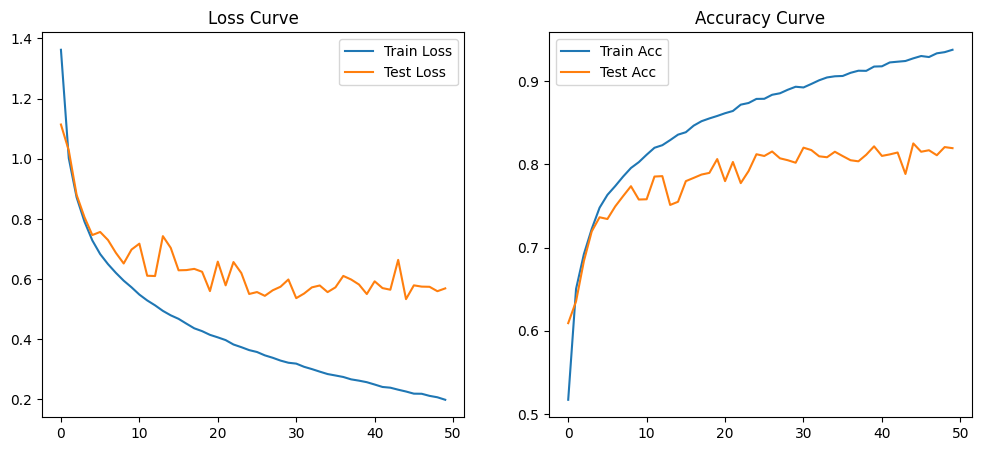

Best Test Accuracy: 0.8251


In [7]:
# 选择模型类型：myconv, conv, dilated, resnet
best_acc = main(model_type="dilated", epochs=50, lr=0.001, batch_size=128)
print(f"Best Test Accuracy: {best_acc:.4f}")